# Constructing the forward model

In source modelling based on OPM/MEG data, the forward model predicts the magnetic fields at the sensors resulting from neural activity in the brain, and is constructed using anatomical data from MRI. It is based on a high-resolution structural (T1) MRI, which is acquired and then segmented to extract the brain, skull, and scalp boundaries; these are used to define a realistic head model and the source space. The MRI is coregistered with the MEG sensor positions to align the coordinate systems. A lead-field matrix is then computed, representing the magnetic field that each potential dipole source would produce at the sensors. This forward model is essential for solving the inverse problem, in which brain activity is estimated from the MEG data using techniques such as minimum-norm estimation or beamforming.

This section covers how to construct the forward model - implemented as a lead-field matrix - to be used in source modelling.

Note that this section requires FreeSurfer (Unix/Linux software) to reconstruct the cortical surfaces; however, we also provide the FreeSurfer output, so the notebook can be run without it.

Question 1 The forward model maps sources to sensors (a well-posed problem), yet estimating the sources from the data — the inverse problem — is ill-posed. Why is the inverse problem ill-posed, and how does an accurate forward model help to constrain it?


## Preparation

Import the relevant Python modules:

In [2]:
import os.path as op
import mne
from mne_bids import BIDSPath, read_raw_bids
from IPython.display import Image, display
from mne_bids import (
    BIDSPath,
    get_anat_landmarks,
    get_head_mri_trans,
    print_dir_tree,
    write_anat,
    write_raw_bids,
)

Set the file names and paths for OPM files"

In [3]:
subject = '01'
session = '01'
task = 'SpAtt'
# name of the task
run = '01'
meg_suffix = 'meg'
mri_suffix = 'T1w'
epo_suffix = 'epo'
bem_suffix = 'bem-sol'
src_suffix = 'src'
fwd_suffix = 'fwd'
trans_suffix = 'trans1'

data_path='E:/Sub_01/Data'

bids_root = op.join(data_path, "Cerca_Spatt_BIDS")
deriv_root = op.join(bids_root, "derivatives/analysis")

fs_subject = 'T1s'
# name of subject from freesurfer
# Files and directories for input
bids_path = BIDSPath(subject=subject, session=session,
task=task, run=run, suffix=epo_suffix, datatype='meg',
root=deriv_root, extension='.fif', check=False)
raw_path = bids_path.copy().update(root=bids_root,
suffix=meg_suffix, extension='.fif', run='01',check=False)

Define the required MRI files 

In [9]:
mri_root = BIDSPath(subject=subject, session=session,
                    root=bids_root,  
                    datatype='anat', suffix=mri_suffix, extension='.nii')

fs_root = 'E:/Sub_01/Data/Cerca_Spatt_BIDS/derivatives/Freesurfer'

and here the output including the transformations:

In [10]:
fwd_fname = bids_path.basename.replace(epo_suffix, fwd_suffix)
fwd_file = op.join(bids_path.directory, fwd_fname)

src_file = fwd_file.replace(fwd_suffix, src_suffix)
trans_file = fwd_file.replace(fwd_suffix, trans_suffix)
bem_file = fwd_file.replace(fwd_suffix, bem_suffix)

## File overview 
The **input OPM** data as well as the epoched data:


In [11]:
print(raw_path)

E:/Sub_01/Data/Cerca_Spatt_BIDS/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_meg.fif


In [12]:
print(bids_path)

E:/Sub_01/Data/Cerca_Spatt_BIDS/derivatives/analysis/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_epo.fif


The **input MRI** files and the Freesurfer derivatives directory:

In [13]:
print("The NIFTI MRI data:   \n",mri_root) 
print("The Freesurfer derivatives: \n",fs_root)

The NIFTI MRI data:   
 E:/Sub_01/Data/Cerca_Spatt_BIDS/sub-01/ses-01/anat/sub-01_ses-01_T1w.nii
The Freesurfer derivatives: 
 E:/Sub_01/Data/Cerca_Spatt_BIDS/derivatives/Freesurfer


The **output** files

In [14]:
print("Forward model:         \n",fwd_file)
print("Brain surface file:    \n",src_file)
print("Tranformation file:    \n",trans_file)
print("Boundary element file: \n",bem_file)

Forward model:         
 E:\Sub_01\Data\Cerca_Spatt_BIDS\derivatives\analysis\sub-01\ses-01\meg\sub-01_ses-01_task-SpAtt_run-01_fwd.fif
Brain surface file:    
 E:\Sub_01\Data\Cerca_Spatt_BIDS\derivatives\analysis\sub-01\ses-01\meg\sub-01_ses-01_task-SpAtt_run-01_src.fif
Tranformation file:    
 E:\Sub_01\Data\Cerca_Spatt_BIDS\derivatives\analysis\sub-01\ses-01\meg\sub-01_ses-01_task-SpAtt_run-01_trans1.fif
Boundary element file: 
 E:\Sub_01\Data\Cerca_Spatt_BIDS\derivatives\analysis\sub-01\ses-01\meg\sub-01_ses-01_task-SpAtt_run-01_bem-sol.fif


## Perform surface reconstruction using FreeSurfer and MNE

A first requirement is that the MRI data are in NifTI (.nii) format. Conversion from DICOM to NifTI can be done e.g. using MRIcro or  dcm2niix.

FreeSurfer provides the functionality for performing the cortical reconstuction using the recon-all.

This must be done in Unix/Linux:

`recon-all -i T1_anon_defaced.nii -s T1_anon_defaced -all`

To perform the scalp surface reconstruction to be used in MNE-Python using the command from the terminal:

`mne make_scalp_surfaces --overwrite --subject T1_anon_defaced --force`

To create the BEM, execute the terminal command:

`mne watershed_bem --overwrite --subject t1_anon_defaced`

For a convinient batch script performing these commands see my_recon.sh on GitHub

The next step is to read and illustrate the brain surface generated from FreeSurfer.


## Inspecting the surface reconstruction

In order to verify that the surface has been constructed and the fif-file created plot the output:

In [15]:
%matplotlib inline
Brain = mne.viz.get_brain_class()

brain = Brain(fs_subject, 
              hemi='lh', 
              surf='pial',
              subjects_dir=fs_root, 
              size=(800, 600))

brain.add_annotation('aparc.a2009s', borders=False)

C:\Users\arakshit\AppData\Local\Temp\ipykernel_20540\3359038428.py:4: RuntimeWarning: The MNE-Python config file (C:\Users\arakshit\.mne\mne-python.json) is not a valid JSON file and might be corrupted
  brain = Brain(fs_subject,


Using pyvistaqt 3d backend.


C:\Users\arakshit\AppData\Local\Temp\ipykernel_20540\3359038428.py:4: RuntimeWarning: The MNE-Python config file (C:\Users\arakshit\.mne\mne-python.json) is not a valid JSON file and might be corrupted
  brain = Brain(fs_subject,
C:\Users\arakshit\AppData\Local\Temp\ipykernel_20540\3359038428.py:4: RuntimeWarning: The MNE-Python config file (C:\Users\arakshit\.mne\mne-python.json) is not a valid JSON file and might be corrupted
  brain = Brain(fs_subject,
C:\Users\arakshit\AppData\Local\Temp\ipykernel_20540\3359038428.py:4: RuntimeWarning: The MNE-Python config file (C:\Users\arakshit\.mne\mne-python.json) is not a valid JSON file and might be corrupted
  brain = Brain(fs_subject,
C:\Users\arakshit\AppData\Local\Temp\ipykernel_20540\3359038428.py:4: RuntimeWarning: The MNE-Python config file (C:\Users\arakshit\.mne\mne-python.json) is not a valid JSON file and might be corrupted
  brain = Brain(fs_subject,
C:\Users\arakshit\AppData\Local\Temp\ipykernel_20540\3359038428.py:4: RuntimeWar

<img src="https://raw.githubusercontent.com/FLUX-pipeline/Cerca/main/brain2.png" width="600">

Above shows the parcellated brain surface. We are not going to use the parcellation here; however, it is wise to use the output to check that the brain surface has been correctly reconstructed.

## Creating the boundary element model (BEM) surfaces

Now that the surface of the MRI has been recontructed the boundary element model (BEM) can be created. As this will be used for MEG source reconstruction, we will prepare a single shell model by setting *conductivity = (0.3)* . The ico parameter serves to downsample the model and it can be increased to reduce the computational demands.

In [16]:
conductivity = (0.3,) 
model = mne.make_bem_model(fs_subject,
                           ico=4,
                           conductivity=conductivity,
                           subjects_dir=fs_root)
bem = mne.make_bem_solution(model)

Creating the BEM geometry...
Going from 5th to 4th subdivision of an icosahedron (n_tri: 20480 -> 5120)
inner skull CM is  -1.88 -24.09  16.08 mm
Surfaces passed the basic topology checks.
Complete.

Homogeneous model surface loaded.
Computing the linear collocation solution...
    Matrix coefficients...
        inner skull (2562) -> inner skull (2562) ...
    Inverting the coefficient matrix...
Solution ready.
BEM geometry computations complete.


Now save the BEM model:

In [17]:
mne.write_bem_solution(bem_file, bem, overwrite=True)

and visualize

Using surface: E:\Sub_01\Data\Cerca_Spatt_BIDS\derivatives\Freesurfer\T1s\bem\inner_skull.surf
Using surface: E:\Sub_01\Data\Cerca_Spatt_BIDS\derivatives\Freesurfer\T1s\bem\outer_skull.surf
Using surface: E:\Sub_01\Data\Cerca_Spatt_BIDS\derivatives\Freesurfer\T1s\bem\outer_skin.surf


C:\Users\arakshit\mne-python\1.10.1_0\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


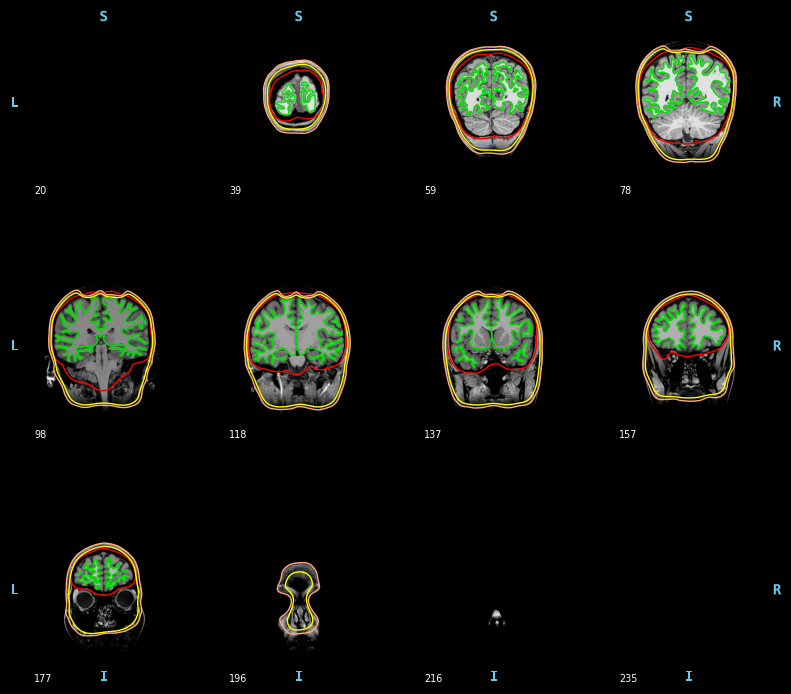

In [18]:
mne.viz.plot_bem(subject=fs_subject,
                subjects_dir=fs_root,
                brain_surfaces='white',
                orientation='coronal');

In the above plots please check that the brain surface has been identified correctly.

Question 2 Here a single-shell BEM (brain only, conductivity 0.3 S/m) is used. Why is a single-shell model adequate for MEG, whereas EEG source modelling generally requires a three-layer model (brain, skull, scalp)?

## Co-registration with anatomical landmarks

The device-to-head transformation, based on digitized scalp landmarks obtained from the 3D scan, is performed using the inbuilt Cerca software (not using HPI coils). The next step is to align the head (in sensor space) with the MRI anatomical space. This spatial alignment is essential for computing the forward solution. To perform this alignment, the MNE-Python coregistration GUI is used, which allows us to visually match the digitized head shape and fiducial points to the MRI surface. For more details on it, please refer to the following video: https://youtu.be/ALV5qqMHLlQ. The output of this manual coregistration process is a transformation file that will be used later in the analysis pipeline.


Load the fif file with the digized data: 

In [19]:
raw = mne.io.read_raw_fif(raw_path, preload=False)

Opening raw data file E:/Sub_01/Data/Cerca_Spatt_BIDS/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_meg.fif...
    Range : 0 ... 1241951 =      0.000 ...  1655.935 secs
Ready.


Now use the co-registration GUI for the alignment (this step can be skipped and the pre-loaded files can be applied): 

In [20]:
%matplotlib qt
mne.gui.coregistration(subject=fs_subject, subjects_dir=fs_root);

C:\Users\arakshit\AppData\Local\Temp\ipykernel_20540\2435276379.py:2: RuntimeWarning: The MNE-Python config file (C:\Users\arakshit\.mne\mne-python.json) is not a valid JSON file and might be corrupted
  mne.gui.coregistration(subject=fs_subject, subjects_dir=fs_root);
C:\Users\arakshit\AppData\Local\Temp\ipykernel_20540\2435276379.py:2: RuntimeWarning: The MNE-Python config file (C:\Users\arakshit\.mne\mne-python.json) is not a valid JSON file and might be corrupted
  mne.gui.coregistration(subject=fs_subject, subjects_dir=fs_root);
C:\Users\arakshit\AppData\Local\Temp\ipykernel_20540\2435276379.py:2: RuntimeWarning: The MNE-Python config file (C:\Users\arakshit\.mne\mne-python.json) is not a valid JSON file and might be corrupted
  mne.gui.coregistration(subject=fs_subject, subjects_dir=fs_root);
C:\Users\arakshit\AppData\Local\Temp\ipykernel_20540\2435276379.py:2: RuntimeWarning: The MNE-Python config file (C:\Users\arakshit\.mne\mne-python.json) is not a valid JSON file and might b

    Triangle neighbors and vertex normals...
Using high resolution head model in E:\Sub_01\Data\Cerca_Spatt_BIDS\derivatives\Freesurfer\T1s\surf\lh.seghead
    Triangle neighbors and vertex normals...
Estimating fiducials from fsaverage.
    Triangle neighbors and vertex normals...
Using high resolution head model in E:\Sub_01\Data\Cerca_Spatt_BIDS\derivatives\Freesurfer\T1s\surf\lh.seghead
    Triangle neighbors and vertex normals...
Estimating fiducials from fsaverage.
Estimating fiducials from fsaverage.
Placing MRI fiducials - LPA
Using lh.seghead for head surface.
Placing MRI fiducials - LPA
Using lh.seghead for head surface.
Placing MRI fiducials - RPA
Placing MRI fiducials - LPA
Using lh.seghead for head surface.
Placing MRI fiducials - NASION
Using lh.seghead for head surface.
Placing MRI fiducials - LPA
Placing MRI fiducials - RPA
Using lh.seghead for head surface.
Using lh.seghead for head surface.
Channel types::	mag: 192
Aligning using fiducials
Start median distance:  12.3

C:\Users\arakshit\mne-python\1.10.1_0\Lib\site-packages\ipykernel\eventloops.py:145: RuntimeWarning: This filename (E:/Sub_01/Data/Cerca_Spatt_BIDS/trans) does not conform to MNE naming conventions. All trans files should end with -trans.fif, -trans.fif.gz, _trans.fif or _trans.fif.gz
  el.exec() if hasattr(el, "exec") else el.exec_()


The transformation will be stored in

In [21]:
print(trans_file)

E:\Sub_01\Data\Cerca_Spatt_BIDS\derivatives\analysis\sub-01\ses-01\meg\sub-01_ses-01_task-SpAtt_run-01_trans1.fif


## Computing the sources according to the BEM model

To construct volumetric forward model, the 'source space' must be set up. The source space is defined by a grid (5 mm between grid points) covering the volume of the brain.

In [22]:
surface = op.join(fs_root, fs_subject, 'bem', 'inner_skull.surf')
src = mne.setup_volume_source_space(fs_subject, subjects_dir=fs_root,
                                     surface=surface,
                                     verbose=True)

Boundary surface file : E:\Sub_01\Data\Cerca_Spatt_BIDS\derivatives\Freesurfer\T1s\bem\inner_skull.surf
grid                  : 5.0 mm
mindist               : 5.0 mm
MRI volume            : E:\Sub_01\Data\Cerca_Spatt_BIDS\derivatives\Freesurfer\T1s\mri\T1.mgz

Reading E:\Sub_01\Data\Cerca_Spatt_BIDS\derivatives\Freesurfer\T1s\mri\T1.mgz...

Loaded bounding surface from E:\Sub_01\Data\Cerca_Spatt_BIDS\derivatives\Freesurfer\T1s\bem\inner_skull.surf (10242 nodes)
Surface CM = (  -1.9  -24.1   16.1) mm
Surface fits inside a sphere with radius   90.9 mm
Surface extent:
    x =  -71.0 ...   67.5 mm
    y =  -99.9 ...   64.9 mm
    z =  -60.3 ...   77.4 mm
Grid extent:
    x =  -75.0 ...   70.0 mm
    y = -100.0 ...   65.0 mm
    z =  -65.0 ...   80.0 mm
30600 sources before omitting any.
22381 sources after omitting infeasible sources not within 0.0 - 90.9 mm.
Source spaces are in MRI coordinates.
Checking that the sources are inside the surface and at least    5.0 mm away (will take a few.

C:\Users\arakshit\AppData\Local\Temp\ipykernel_20540\1012623490.py:2: RuntimeWarning: The MNE-Python config file (C:\Users\arakshit\.mne\mne-python.json) is not a valid JSON file and might be corrupted
  src = mne.setup_volume_source_space(fs_subject, subjects_dir=fs_root,
C:\Users\arakshit\AppData\Local\Temp\ipykernel_20540\1012623490.py:2: RuntimeWarning: The MNE-Python config file (C:\Users\arakshit\.mne\mne-python.json) is not a valid JSON file and might be corrupted
  src = mne.setup_volume_source_space(fs_subject, subjects_dir=fs_root,


    Found   573/ 8921 points outside using solid angles
    Total 12292/22381 points inside the surface
Interior check completed in 20943.8 ms
    10089 source space points omitted because they are outside the inner skull surface.
    2506 source space points omitted because of the    5.0-mm distance limit.
9786 sources remaining after excluding the sources outside the surface and less than    5.0 mm inside.
Adjusting the neighborhood info.
Source space : MRI voxel -> MRI (surface RAS)
    0.005000 0.000000 0.000000     -75.00 mm
    0.000000 0.005000 0.000000    -100.00 mm
    0.000000 0.000000 0.005000     -65.00 mm
    0.000000 0.000000 0.000000       1.00
MRI volume : MRI voxel -> MRI (surface RAS)
    -0.001000 0.000000 0.000000     128.00 mm
    0.000000 0.000000 0.001000    -128.00 mm
    0.000000 -0.001000 0.000000     128.00 mm
    0.000000 0.000000 0.000000       1.00
MRI volume : MRI (surface RAS) -> RAS (non-zero origin)
    1.000000 0.000000 0.000000       1.00 mm
    0.00


and then save it:

In [23]:
mne.write_source_spaces(src_file, src, overwrite=True)

    Write a source space...
    [done]
    1 source spaces written


Using surface: E:\Sub_01\Data\Cerca_Spatt_BIDS\derivatives\Freesurfer\T1s\bem\inner_skull.surf
Using surface: E:\Sub_01\Data\Cerca_Spatt_BIDS\derivatives\Freesurfer\T1s\bem\outer_skull.surf
Using surface: E:\Sub_01\Data\Cerca_Spatt_BIDS\derivatives\Freesurfer\T1s\bem\outer_skin.surf


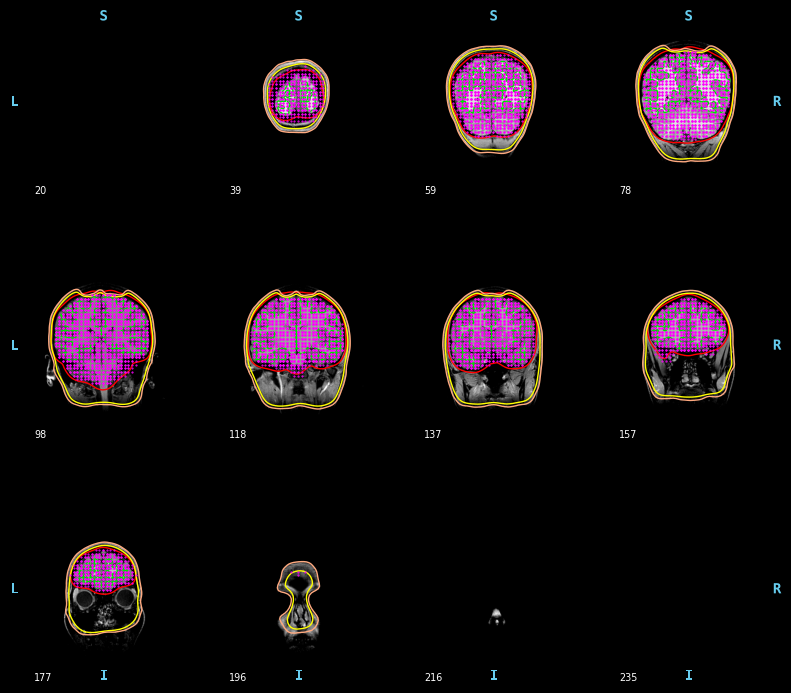

In [24]:
mne.viz.plot_bem(subject=fs_subject, 
                     subjects_dir=fs_root,
                     brain_surfaces='white', 
                     src=src, 
                     orientation='coronal')

Note that the grid converts the brain.



Question 3 The source space is a volumetric 5 mm grid. How would halving the grid spacing (5 mm → 2.5 mm) affect the number of sources, the computation time, and the spatial resolution of the final source estimate? Is finer always better?


## Alignment checking
Now check the alignment

In [25]:
info = raw.info
print(info)
mne.viz.plot_alignment(info, 
                       trans=trans_file, 
                       subject=fs_subject,
                       dig=True,
                       meg=['helmet', 'sensors'],
                       subjects_dir=fs_root,
                       surfaces={"head": 0.1,"inner_skull": 0.2, "white": 1.0},
                       bem=bem,
                       src=src
                      )

<Info | 15 non-empty values
 bads: []
 ch_names: Trigger 1, Trigger 2, Trigger 3, Trigger 4, Trigger 5, Trigger ...
 chs: 27 Stimulus, 192 Magnetometers
 custom_ref_applied: False
 description: Anonymized using a time shift to preserve age at acquisition
 dev_head_t: MEG device -> head transform
 device_info: 2 items (dict)
 dig: 4309 items (3 Cardinal, 4306 Extra)
 experimenter: mne_anonymize
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 line_freq: 50.0
 lowpass: 250.0 Hz
 meas_date: unspecified
 meas_id: 4 items (dict)
 nchan: 219
 projs: []
 sfreq: 750.0 Hz
>


C:\Users\arakshit\AppData\Local\Temp\ipykernel_20540\4275533942.py:3: RuntimeWarning: The MNE-Python config file (C:\Users\arakshit\.mne\mne-python.json) is not a valid JSON file and might be corrupted
  mne.viz.plot_alignment(info,
C:\Users\arakshit\AppData\Local\Temp\ipykernel_20540\4275533942.py:3: RuntimeWarning: The MNE-Python config file (C:\Users\arakshit\.mne\mne-python.json) is not a valid JSON file and might be corrupted
  mne.viz.plot_alignment(info,
C:\Users\arakshit\AppData\Local\Temp\ipykernel_20540\4275533942.py:3: RuntimeWarning: The MNE-Python config file (C:\Users\arakshit\.mne\mne-python.json) is not a valid JSON file and might be corrupted
  mne.viz.plot_alignment(info,


Could not find the surface for head in the provided BEM model, looking in the subject directory.
Using outer_skin.surf for head surface.
Getting helmet for system unknown (derived from 192 MEG channel locations)


C:\Users\arakshit\AppData\Local\Temp\ipykernel_20540\4275533942.py:3: RuntimeWarning: The MNE-Python config file (C:\Users\arakshit\.mne\mne-python.json) is not a valid JSON file and might be corrupted
  mne.viz.plot_alignment(info,


Channel types::	mag: 192


<img src="https://raw.githubusercontent.com/FLUX-pipeline/Cerca/main/alignmentcheck.png">



Question 4 OPMs are placed closer to the scalp than conventional SQUID sensors, and their positions and orientations come from the Cerca system rather than a fixed helmet. Why does this make an accurate forward model — sensor positions together with coregistration — especially critical for OPM source reconstruction?


## Construting the forward model

The last step is to construct the forward model by assigning a lead-field to each source location in relation to the head position with respect to the sensors. This will result in the lead-field matrix (fwd).

In [26]:
fwd = mne.make_forward_solution(info, 
                                trans=trans_file,
                                src=src, 
                                bem=bem,
                                meg=True, 
                                eeg=False, 
                                mindist=5.,  #TODO: minimum distance of sources from inner skull surface (in mm); can be 2.5
                                n_jobs=-1, 
                                verbose=True)

Source space          : <SourceSpaces: [<volume, shape=(np.int64(30), np.int64(34), np.int64(30)), n_used=9786>] MRI (surface RAS) coords, subject 'T1s', ~135.6 MiB>
MRI -> head transform : E:\Sub_01\Data\Cerca_Spatt_BIDS\derivatives\analysis\sub-01\ses-01\meg\sub-01_ses-01_task-SpAtt_run-01_trans1.fif
Measurement data      : instance of Info
Conductor model   : instance of ConductorModel
Accurate field computations
Do computations in head coordinates
Free source orientations

Read 1 source spaces a total of 9786 active source locations

Coordinate transformation: MRI (surface RAS) -> head
    0.996696 -0.062715 -0.051614       2.02 mm
    0.078834 0.899920 0.428869      25.42 mm
    0.019552 -0.431521 0.901891      21.34 mm
    0.000000 0.000000 0.000000       1.00

Read 192 MEG channels from info
105 coil definitions read
Coordinate transformation: MEG device -> head
    0.992475 -0.034691 0.117427       6.34 mm
    0.065516 0.960650 -0.269926      15.90 mm
    -0.103442 0.275588 0.9

C:\Users\arakshit\AppData\Local\Temp\ipykernel_20540\2405492327.py:1: RuntimeWarning: The MNE-Python config file (C:\Users\arakshit\.mne\mne-python.json) is not a valid JSON file and might be corrupted
  fwd = mne.make_forward_solution(info,
C:\Users\arakshit\AppData\Local\Temp\ipykernel_20540\2405492327.py:1: RuntimeWarning: The MNE-Python config file (C:\Users\arakshit\.mne\mne-python.json) is not a valid JSON file and might be corrupted
  fwd = mne.make_forward_solution(info,
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of  16 | elapsed:  1.0min remaining:  2.3min
[Parallel(n_jobs=-1)]: Done   9 out of  16 | elapsed:  1.0min remaining:   48.3s
[Parallel(n_jobs=-1)]: Done  13 out of  16 | elapsed:  1.0min remaining:   14.3s


    Found    0/5866 points outside using solid angles
    Total 9786/9786 points inside the surface
Interior check completed in 63538.1 ms

Checking surface interior status for 192 points...
    Found   0/192 points inside  an interior sphere of radius   49.1 mm
    Found 183/192 points outside an exterior sphere of radius   90.9 mm
    Found   9/  9 points outside using surface Qhull
    Found   0/  0 points outside using solid angles
    Total 0/192 points inside the surface
Interior check completed in 37.5 ms

Composing the field computation matrix...


[Parallel(n_jobs=-1)]: Done  16 out of  16 | elapsed:  1.1min finished
C:\Users\arakshit\AppData\Local\Temp\ipykernel_20540\2405492327.py:1: RuntimeWarning: The MNE-Python config file (C:\Users\arakshit\.mne\mne-python.json) is not a valid JSON file and might be corrupted
  fwd = mne.make_forward_solution(info,
C:\Users\arakshit\AppData\Local\Temp\ipykernel_20540\2405492327.py:1: RuntimeWarning: The MNE-Python config file (C:\Users\arakshit\.mne\mne-python.json) is not a valid JSON file and might be corrupted
  fwd = mne.make_forward_solution(info,
C:\Users\arakshit\AppData\Local\Temp\ipykernel_20540\2405492327.py:1: RuntimeWarning: The MNE-Python config file (C:\Users\arakshit\.mne\mne-python.json) is not a valid JSON file and might be corrupted
  fwd = mne.make_forward_solution(info,
C:\Users\arakshit\AppData\Local\Temp\ipykernel_20540\2405492327.py:1: RuntimeWarning: The MNE-Python config file (C:\Users\arakshit\.mne\mne-python.json) is not a valid JSON file and might be corrupted
 

Computing MEG at 9786 source locations (free orientations)...


[Parallel(n_jobs=-1)]: Done  13 out of  16 | elapsed:    3.2s remaining:    0.7s
[Parallel(n_jobs=-1)]: Done  16 out of  16 | elapsed:    3.3s finished
C:\Users\arakshit\AppData\Local\Temp\ipykernel_20540\2405492327.py:1: RuntimeWarning: The MNE-Python config file (C:\Users\arakshit\.mne\mne-python.json) is not a valid JSON file and might be corrupted
  fwd = mne.make_forward_solution(info,
C:\Users\arakshit\AppData\Local\Temp\ipykernel_20540\2405492327.py:1: RuntimeWarning: The MNE-Python config file (C:\Users\arakshit\.mne\mne-python.json) is not a valid JSON file and might be corrupted
  fwd = mne.make_forward_solution(info,
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of  16 | elapsed:    2.0s remaining:    4.4s
[Parallel(n_jobs=-1)]: Done   9 out of  16 | elapsed:    2.2s remaining:    1.7s
[Parallel(n_jobs=-1)]: Done  13 out of  16 | elapsed:    2.5s remaining:    0.5s
[Parallel(n_jobs=-1)]: Done  16 out of  16 |


Finished.


[Parallel(n_jobs=16)]: Done   5 out of  16 | elapsed:    0.5s remaining:    1.3s
[Parallel(n_jobs=16)]: Done   9 out of  16 | elapsed:    0.6s remaining:    0.4s
[Parallel(n_jobs=16)]: Done  13 out of  16 | elapsed:    0.6s remaining:    0.1s
[Parallel(n_jobs=16)]: Done  16 out of  16 | elapsed:    0.6s finished


#### Finally, save the forward models:

In [27]:
mne.write_forward_solution(fwd_file, fwd, overwrite=True)

    Write a source space...
    [done]
    1 source spaces written


## Preregistraion and publications



A preregistration should describe the anatomical pipeline and forward model in enough detail to reproduce them exactly. The MRI processing, head model, source space, and coregistration all shape the forward solution, so these choices should be fixed in advance. We recommend committing to the following:

MRI and surface reconstruction

    The MRI acquisition (scanner, sequence, key parameters) and the DICOM→NIfTI conversion.
    The reconstruction software and versions (here FreeSurfer recon-all [1,2], plus MNE-Python's make_scalp_surfaces and watershed_bem).

Head model and source space

    The BEM type and conductivity (here a single-shell model, conductivity 0.3 S/m, ico=4), which is appropriate for MEG.
    The source space (here a volumetric grid, 5 mm spacing, bounded by the inner-skull surface) and the minimum source-to-skull distance (here 5 mm).

Coregistration

    How the MEG and MRI coordinate systems are aligned (here landmark- and head-shape-based coregistration in the MNE-Python GUI, using the Cerca 3D-scan digitisation rather than HPI coils), and who performed it.

General

    Software and versions (FreeSurfer, MNE-Python, MNE-BIDS).
    Where the forward model and its inputs are stored (*_fwd.fif, *_src.fif, *_bem-sol.fif, *_trans1.fif).

Example methods text

    "Structural magnetic resonance imaging (MRI) data were acquired using a 3 Tesla Siemens MAGNETOM Prisma whole-body scanner (Siemens AG; TE = 2 ms, TR = 2 s). The raw T1-weighted images were converted from DICOM to NIfTI format and reconstructed with FreeSurfer [1,2]. Each participant's MRI coordinate system was aligned to anatomical landmarks (the nasion and the left and right preauricular points) and to the scalp shape digitised prior to data acquisition; alignment to the MEG sensor array was performed relative to the head surface obtained from the 3D scan. A single-shell boundary element model (BEM) was constructed from the brain surface extracted by FreeSurfer and used to generate a volumetric forward model on a 5 mm grid covering the brain. The lead-field matrix was then computed from the participant's head position relative to the MEG sensor array, as implemented in MNE-Python [3]."



## References

1. Dale, A.M., Fischl, B., & Sereno, M.I. (1999). Cortical surface-based analysis: I. Segmentation and surface reconstruction. *NeuroImage*, **9**(2), 179–194. https://doi.org/10.1006/nimg.1998.0395
2. Destrieux, C., Fischl, B., Dale, A., & Halgren, E. (2010). Automatic parcellation of human cortical gyri and sulci using standard anatomical nomenclature. *NeuroImage*, **53**(1), 1–15. https://doi.org/10.1016/j.neuroimage.2010.06.010
